<a href="https://colab.research.google.com/github/NagaSatyaPavani1234/Restaurent-Review-Sentiment-Analysis/blob/main/Restaurent_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Restaurant Review Sentiment Analysis using NLP



# Installing required libraries

In [ ]:
!pip install nltk textblob pandas matplotlib

# Importing required libraries

In [ ]:
# Import libraries
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Downloading NLTK resources

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Load Dataset

In [ ]:
df=pd.read_csv('restaurant_reviews.csv')

# Displaying Dataset Values

In [ ]:
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


# Information of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


# Data Preprocessing

In [ ]:
# @title Checking for the null values in the dataset
df.isnull().sum()

,0
Review,0
Liked,0


In [ ]:
# @title Checking for duplicate in the dataset
df.duplicated().sum()

np.int64(4)

In [ ]:
# @title Dropping or Removing duplicate values
df=df.drop_duplicates()

# Statistical summary of the datset

In [ ]:
df.describe()

,Liked
count,996.000000
mean,0.501004
std,0.500250
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


# Text preprocessing

In [ ]:
# Stopwords list
stop_words = set(stopwords.words('english'))
# Preprocessing function
def preprocess(text):
    tokens = word_tokenize(text.lower())
    filtered_words = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(filtered_words)
# Apply preprocessing
df["clean_review"] = df["Review"].apply(preprocess)
df.head()

/tmp/ipykernel_857/752771436.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_review"] = df["Review"].apply(preprocess)


,Review,Liked,clean_review
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good.,0,crust good
2,Not tasty and the texture was just nasty.,0,tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great prices


# Feature Engineering


In [ ]:
# @title Adding sentiment score feature
# Calculate sentiment score
df["sentiment_score"] = df["clean_review"].apply(lambda x: TextBlob(x).sentiment.polarity)
df.head()

/tmp/ipykernel_857/3968454397.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment_score"] = df["clean_review"].apply(lambda x: TextBlob(x).sentiment.polarity)


,Review,Liked,clean_review,sentiment_score
0,Wow... Loved this place.,1,wow loved place,0.4
1,Crust is not good.,0,crust good,0.7
2,Not tasty and the texture was just nasty.,0,tasty texture nasty,-1.0
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...,0.2
4,The selection on the menu was great and so wer...,1,selection menu great prices,0.8


In [ ]:
# @title Adding Sentiment label feature
# Function to classify sentiment
def classify_sentiment(score):

    if score > 0.3:
        return "Positive"

    elif score < -0.3:
        return "Negative"

    else:
        return "Neutral"

# Apply classification
df["Sentiment"] = df["sentiment_score"].apply(classify_sentiment)

df.head()

/tmp/ipykernel_857/3366573671.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sentiment"] = df["sentiment_score"].apply(classify_sentiment)


,Review,Liked,clean_review,sentiment_score,Sentiment
0,Wow... Loved this place.,1,wow loved place,0.4,Positive
1,Crust is not good.,0,crust good,0.7,Positive
2,Not tasty and the texture was just nasty.,0,tasty texture nasty,-1.0,Negative
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...,0.2,Neutral
4,The selection on the menu was great and so wer...,1,selection menu great prices,0.8,Positive


In [ ]:
# @title Adding Review length feature
df["review_length"] = df["Review"].apply(lambda x: len(x.split()))
df.head()

/tmp/ipykernel_857/249823289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review_length"] = df["Review"].apply(lambda x: len(x.split()))


,Review,Liked,clean_review,sentiment_score,Sentiment,review_length
0,Wow... Loved this place.,1,wow loved place,0.4,Positive,4
1,Crust is not good.,0,crust good,0.7,Positive,4
2,Not tasty and the texture was just nasty.,0,tasty texture nasty,-1.0,Negative,8
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...,0.2,Neutral,15
4,The selection on the menu was great and so wer...,1,selection menu great prices,0.8,Positive,12


# Plotting sentiment distribution

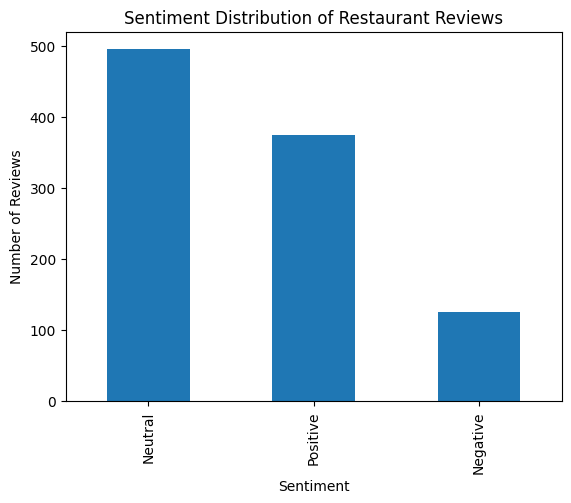

In [ ]:
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Restaurant Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Plotting sentiment score

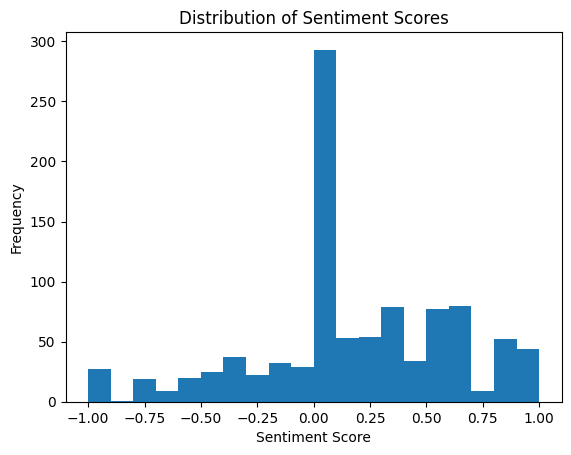

In [ ]:
plt.hist(df["sentiment_score"], bins=20)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

# Testing

In [ ]:
from textblob import TextBlob

user_text = input("Enter text: ")

processed_text = preprocess(user_text)

blob = TextBlob(processed_text)
score = blob.sentiment.polarity
prediction = classify_sentiment(score)

print("\nPrediction Result")
print("Text:", user_text)
print("Predicted Sentiment:", prediction)

# Additional features
print("\n--- Additional Analysis ---")
print("Text Length:", len(user_text))
print("Word Count:", len(user_text.split()))

if len(user_text.split()) > 10:
    print("Review Type: Detailed Review")
else:
    print("Review Type: Short Review")

Enter text: hey the food is good

Prediction Result
Text: hey the food is good
Predicted Sentiment: Positive

--- Additional Analysis ---
Text Length: 20
Word Count: 5
Review Type: Short Review
